<a href="https://colab.research.google.com/github/adrianestebanrodriguez/Repositorio_Datasets/blob/main/calidadpan8mayo2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Estadísticas descriptivas ===
                peso        volumen        humedad             pH  \
count  200000.000000  200000.000000  200000.000000  200000.000000   
mean      500.029219     799.959066      37.504861       6.200130   
std        29.997619      50.036068       4.326768       0.199898   
min       366.031884     579.305702      30.000079       5.336107   
25%       479.777921     766.170576      33.775381       6.065009   
50%       500.051093     799.984599      37.486959       6.200483   
75%       520.282781     833.619390      41.252860       6.335274   
max       636.863442    1010.968317      44.999924       7.135790   

       temperatura_horno  tiempo_horneado       densidad         rotura  \
count      200000.000000    200000.000000  200000.000000  200000.000000   
mean          219.983717        29.997068       0.619860       0.099845   
std             5.002740         2.006006       0.030020       0.299794   
min           197.015259        20.711162   

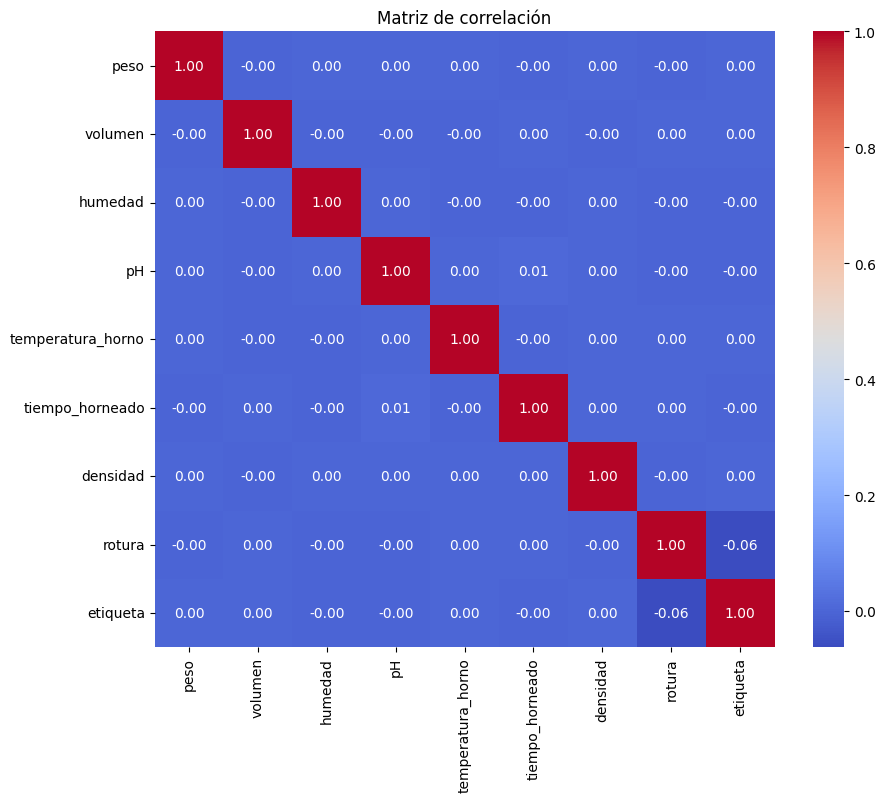


Entrenando LogisticRegression …
{'accuracy': 0.40005, 'precision': 0.363073075854404, 'recall': 0.9239852920379013, 'f1': 0.5213037580786724, 'auc': np.float64(0.5260160610435075)}

Entrenando DecisionTree …
{'accuracy': 0.555975, 'precision': 0.37254349510459955, 'recall': 0.3739923631735257, 'f1': 0.37326652316595504, 'auc': np.float64(0.5147477478331857)}

Entrenando RandomForest …
{'accuracy': 0.6387, 'precision': 0.43809904153354634, 'recall': 0.0775703577994626, 'f1': 0.1318034362609636, 'auc': np.float64(0.5793733934687778)}

Entrenando XGBoost …


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:03:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'accuracy': 0.554675, 'precision': 0.41078112088659896, 'recall': 0.5975816716164616, 'f1': 0.4868788708051275, 'auc': np.float64(0.5877713268682732)}


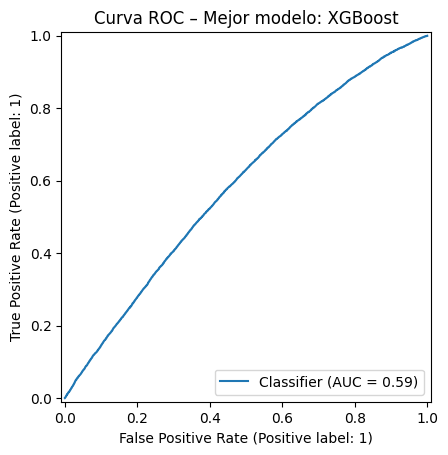

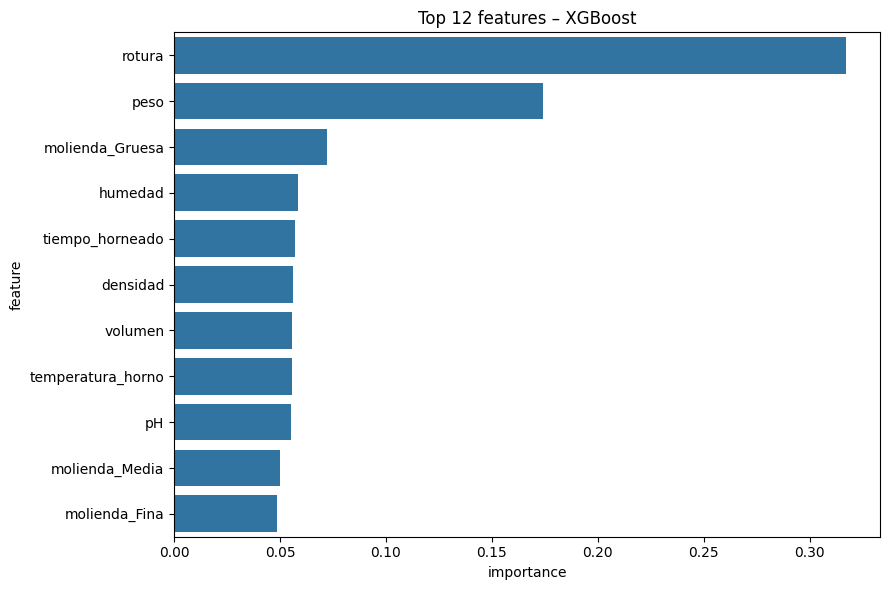

In [ ]:
# control_calidad_pan.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# ------------------------------------------------------------------
# 1️⃣ Generar dataset sintético (puedes remplazarlo por tu CSV)
np.random.seed(42)
n = 200000
data = pd.DataFrame({
    "peso": np.random.normal(500, 30, n),
    "volumen": np.random.normal(800, 50, n),
    "humedad": np.random.uniform(30, 45, n),
    "pH": np.random.normal(6.2, 0.2, n),
    "temperatura_horno": np.random.normal(220, 5, n),
    "tiempo_horneado": np.random.normal(30, 2, n),
    "densidad": np.random.normal(0.62, 0.03, n),
    "rotura": np.random.binomial(1, 0.1, n),
    "molienda": np.random.choice(["Fina", "Media", "Gruesa"], n, p=[0.5, 0.35, 0.15])
})

# Simular etiqueta (0=aprobado, 1=rechazado) con una regla no lineal
def generar_etiqueta(row):
    score = (
        -0.02*abs(row["peso"]-500) +
        -0.03*abs(row["humedad"]-37) +
        -0.5*row["rotura"] +
        (0.1 if row["molienda"] == "Gruesa" else 0)
    )
    prob = 1/(1+np.exp(-score))
    return np.random.binomial(1, prob)

data["etiqueta"] = data.apply(generar_etiqueta, axis=1)

# ------------------------------------------------------------------
# 2️⃣ EDA rápida (puedes comentar si no lo necesitas)
def eda(df):
    print("=== Estadísticas descriptivas ===")
    print(df.describe())
    print("\n=== Distribución de la etiqueta ===")
    print(df["etiqueta"].value_counts(normalize=True))
    # Matriz de correlación
    corr = df.select_dtypes(include=["float64", "int64"]).corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Matriz de correlación")
    plt.show()

eda(data)   # <-- descomenta para visualizar

# ------------------------------------------------------------------
# 3️⃣ Pre‑procesamiento y división
X = data.drop(columns=["etiqueta"])
y = data["etiqueta"]

numeric_features = ["peso","volumen","humedad","pH","temperatura_horno",
                    "tiempo_horneado","densidad","rotura"]
categorical_features = ["molienda"]

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ------------------------------------------------------------------
# 4️⃣ Modelos a entrenar
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "DecisionTree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42
    ),
    "XGBoost": xgb.XGBClassifier(
        eval_metric="logloss", use_label_encoder=False,
        scale_pos_weight=(y==0).sum()/(y==1).sum(), random_state=42
    )
}

def evaluate(model, X_tr, X_te, y_tr, y_te):
    # Pipeline completa: pre‑procesamiento + modelo
    pipe = Pipeline(steps=[("preprocess", preprocess),
                          ("model", model)])
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    y_proba = pipe.predict_proba(X_te)[:,1]

    metrics = {
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred),
        "recall": recall_score(y_te, y_pred),
        "f1": f1_score(y_te, y_pred),
        "auc": roc_auc_score(y_te, y_proba)
    }
    return pipe, metrics

results = {}
for name, mdl in models.items():
    print(f"\nEntrenando {name} …")
    pipe, mets = evaluate(mdl, X_train, X_test, y_train, y_test)
    results[name] = {"pipeline": pipe, "metrics": mets}
    print(mets)

# ------------------------------------------------------------------
# 5️⃣ Visualizar la mejor curva ROC
best_name = max(results, key=lambda k: results[k]["metrics"]["auc"])
best_pipe = results[best_name]["pipeline"]
y_proba_best = best_pipe.predict_proba(X_test)[:,1]

RocCurveDisplay.from_predictions(y_test, y_proba_best)
plt.title(f"Curva ROC – Mejor modelo: {best_name}")
plt.show()

# ------------------------------------------------------------------
# 6️⃣ Importancia de variables (solo para RandomForest / XGBoost)
if best_name in ["RandomForest", "XGBoost"]:
    importances = best_pipe.named_steps["model"].feature_importances_
    # Obtener nombres después del One‑Hot
    ohe = best_pipe.named_steps["preprocess"].named_transformers_["cat"]["onehot"]
    cat_names = ohe.get_feature_names_out(categorical_features)
    feature_names = numeric_features + list(cat_names)
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False)

    plt.figure(figsize=(9,6))
    sns.barplot(x="importance", y="feature", data=imp_df.head(12))
    plt.title(f"Top 12 features – {best_name}")
    plt.tight_layout()
    plt.show()

### Optimización de Hiperparámetros para XGBoost con `GridSearchCV`
Aquí realizaremos una búsqueda en cuadrícula de algunos hiperparámetros clave para el modelo XGBoost para intentar mejorar su rendimiento. Debido al tiempo de ejecución, la cuadrícula se ha mantenido relativamente pequeña.

Iniciando búsqueda de hiperparámetros para XGBoost...
Fitting 3 folds for each of 108 candidates, totalling 324 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:22:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Búsqueda de hiperparámetros finalizada.
Mejores parámetros encontrados: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Mejor score (AUC) de validación cruzada: 0.6031

Métricas de evaluación para el modelo XGBoost optimizado:
{'accuracy': 0.558225, 'precision': 0.41799507366268535, 'recall': 0.6359779380568519, 'f1': 0.5044448806752854, 'auc': np.float64(0.6041829272978858)}


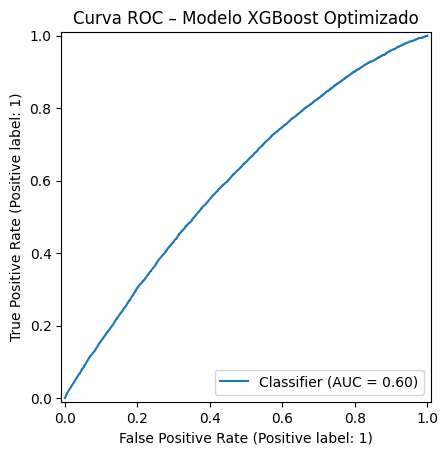

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definimos el modelo XGBoost con los parámetros iniciales
xgb_model_tuned = xgb.XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=(y==0).sum()/(y==1).sum(),
    random_state=42
)

# Definimos el pipeline completo con el pre-procesamiento y el modelo XGBoost
pipe_xgb_tuned = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_model_tuned)])

# Definimos la cuadrícula de hiperparámetros a buscar
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 0.8],
    'model__colsample_bytree': [0.7, 0.8]
}

# Configuramos GridSearchCV
# Usamos 'roc_auc' como métrica de puntuación debido al desequilibrio de clases.
# cv=3 para validación cruzada con 3 folds (puedes aumentar si el tiempo lo permite).
# n_jobs=-1 para usar todos los núcleos del procesador.
grid_search = GridSearchCV(pipe_xgb_tuned, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)

print("Iniciando búsqueda de hiperparámetros para XGBoost...")
grid_search.fit(X_train, y_train)

print("Búsqueda de hiperparámetros finalizada.")
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor score (AUC) de validación cruzada: {grid_search.best_score_:.4f}")

# Obtenemos el mejor modelo
best_xgb_model = grid_search.best_estimator_

# Evaluamos el mejor modelo en el conjunto de prueba
y_pred_tuned = best_xgb_model.predict(X_test)
y_proba_tuned = best_xgb_model.predict_proba(X_test)[:,1]

metrics_tuned = {
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "precision": precision_score(y_test, y_pred_tuned),
    "recall": recall_score(y_test, y_pred_tuned),
    "f1": f1_score(y_test, y_pred_tuned),
    "auc": roc_auc_score(y_test, y_proba_tuned)
}

print("\nMétricas de evaluación para el modelo XGBoost optimizado:")
print(metrics_tuned)

# Visualizar la Curva ROC del modelo optimizado
RocCurveDisplay.from_predictions(y_test, y_proba_tuned)
plt.title("Curva ROC – Modelo XGBoost Optimizado")
plt.show()

### Comparación de Matrices de Confusión (Modelo Original vs. Optimizado)

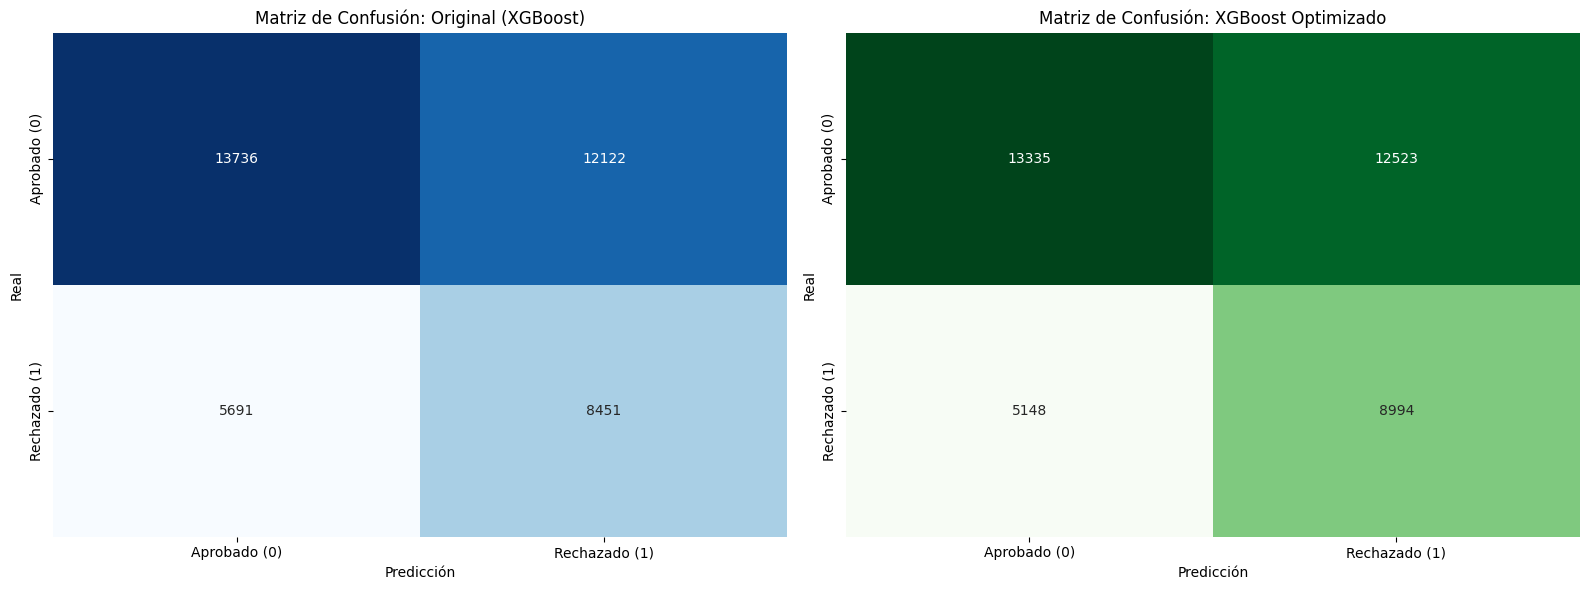

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de confusión del modelo original (ya calculada en `cm`)
# y_pred_best = best_pipe.predict(X_test)
# cm_original = confusion_matrix(y_test, y_pred_best)
cm_original = cm # cm already contains the confusion matrix for the best original model

# Matriz de confusión del modelo optimizado
y_pred_tuned = best_xgb_model.predict(X_test)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visualizar la matriz de confusión del modelo original
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Aprobado (0)', 'Rechazado (1)'],
            yticklabels=['Aprobado (0)', 'Rechazado (1)'], ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title(f'Matriz de Confusión: Original ({best_name})')

# Visualizar la matriz de confusión del modelo optimizado
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Aprobado (0)', 'Rechazado (1)'],
            yticklabels=['Aprobado (0)', 'Rechazado (1)'], ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusión: XGBoost Optimizado')

plt.tight_layout()
plt.show()

### Matriz de Confusión para el Mejor Modelo

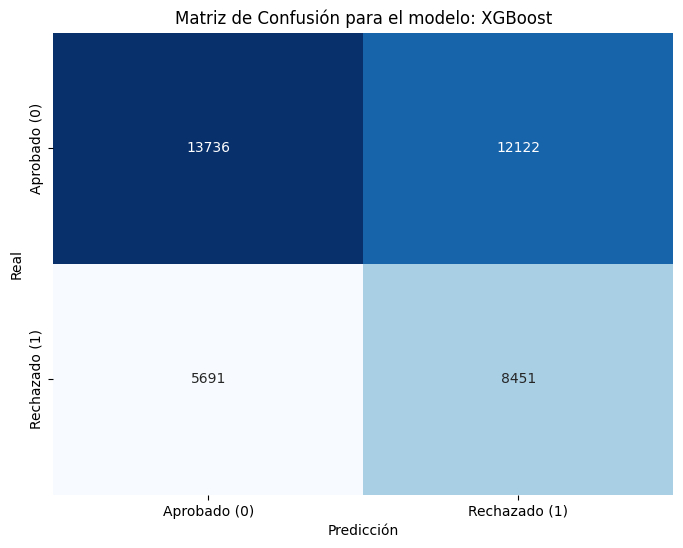

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Obtener las predicciones del mejor modelo en el conjunto de prueba
y_pred_best = best_pipe.predict(X_test)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred_best)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Aprobado (0)', 'Rechazado (1)'],
            yticklabels=['Aprobado (0)', 'Rechazado (1)'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f'Matriz de Confusión para el modelo: {best_name}')
plt.show()